# Test for MCMC implementation

## Generate data

In [1]:
import numpy
import random

In [2]:
# For reproducibility
seed = 2
rng = numpy.random.default_rng(seed=seed)

In [3]:
# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534 # Nuiusance parameter: the std dev. of the Gaussian noise in the data

In [4]:
# Generate some synthetic data from the model.
N = 50
xobs = numpy.sort(10 * rng.normal(size=N))
yerr = 0.1 + .5 * rng.normal(size=N)
yobs = m_true * xobs + b_true
yobs += numpy.abs(f_true * yobs) * rng.standard_normal(size=N)
yobs += yerr * rng.standard_normal(size=N)
yerr = numpy.abs(yerr)

## LogLikelihood and Prior


In [5]:
prior = [
    [-2.0,0.0],
    [2.0,6.0],
    [-4.0, 4.0]
]

def log_likelihood(theta, xx, yy, ee):
    ''' The log-likelihood function for the model.'''
    pass
    if theta.shape != (3,):
        raise ValueError('theta must be a 3-element array: (m, b, log_f)')
    m, b, log_f = theta
    model = m * xx + b
    sigma2 = ee**2 + model**2 * numpy.exp(2 * log_f)
    return -0.5 * numpy.sum((yy - model) ** 2 / sigma2 + numpy.log(sigma2))

def log_prior(theta, prior):
    ''' The log-prior function for the model.'''
    if theta.shape != (3,):
        raise ValueError('theta must be a 3-element array: (m, b, log_f)')
    m, b, log_f = theta
    mlim, blim, flim = prior
    if mlim[0] < m < mlim[1] and blim[0] < b < blim[1] and flim[0] < log_f < flim[1]:
        return 0.0
    return -numpy.inf

def log_posterior(theta, xx, yy, ee, prior):
    ''' The log-posterior function'''
    # require a prior argument
    if prior is None:
        raise ValueError('prior must be supplied')
    lp = log_prior(theta, prior)
    if not numpy.isfinite(lp): # why not just implement it in "else" in prior?
        return -numpy.inf
    return lp + log_likelihood(theta, xx, yy, ee)

## Use MCMC developed by Marta

In [ ]:
#%reset -f



In [221]:
import importlib
importlib.reload(MCMC_marta.MCMC_numpy_optimized)   # reload the module to reflect recent edits
import MCMC_marta.MCMC_numpy_optimized as MCMC
#help(MCMC_marta.MCMC_numpy.MHsampler)


In [222]:
nwalkers = 4
ndim = 3

sampler = MCMC.MHsampler(nwalkers, log_posterior, prior, ndim)
sampler.seed_rng(2)

In [227]:

#help(sampler.run)
sampler.run(10000, mode = 'random', xx= xobs, yy=yobs, ee=yerr, prior=prior)

sampler.get_flat_chain()


array([[-1.47677573,  3.19396457,  2.51380592],
       [-1.81616812,  4.4004021 ,  1.82848421],
       [-1.62419785,  2.22058651, -1.80024506],
       ...,
       [-0.97730528,  4.44821522, -0.78951343],
       [-0.94784198,  4.0332962 , -0.58705756],
       [-0.98744598,  4.27075207, -0.67534115]], shape=(40000, 3))

Removed no burn in


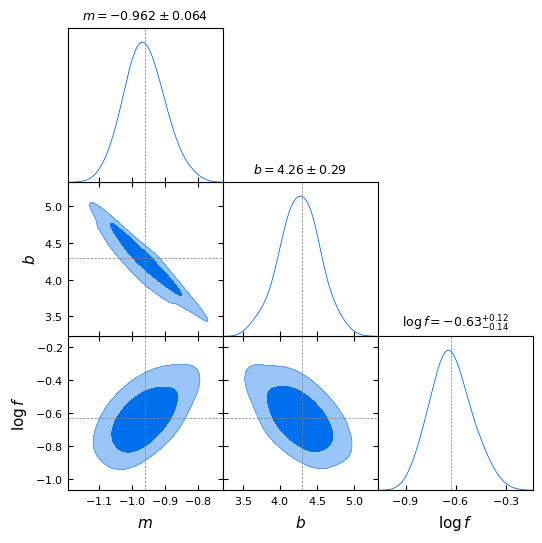

In [228]:
from getdist import MCSamples, plots

outchain = sampler.get_flat_chain(burnin=1000)



samples = MCSamples(
    samples=outchain[::5],
    names=["m","b","logf"],
    labels=["m","b","\\log f"],
    #settings={"smooth_scale_2D": 0.8,"smooth_scale_1D": 0.8},
    #smooth_scale_1D=0.5,
    #smooth_scale_2D=0.5
)

g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 2

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4
g.settings.title_limit_fontsize = 12

g.triangle_plot(
    samples, 
    filled=True,     
    markers={
        "m": m_true,
        "b": b_true,
        "logf": numpy.log(f_true)
    },
    title_limit=1)


#g.save

In [300]:
#import importlib
importlib.reload(MCMC_marta.MCMC_parallel)   # reload the module to reflect recent edits
import MCMC_marta.MCMC_parallel as MCMC
#help(MCMC_marta.MCMC_numpy.MHsampler)


In [301]:
nwalkers = 16
ndim = 3

sampler = MCMC.MHsampler(nwalkers, log_posterior, prior, ndim)
#sampler.seed_rng(128)

In [302]:

#help(sampler.run)
sampler.run(10000, mode = 'random', verbose=False, xx= xobs, yy=yobs, ee=yerr, prior=prior)

sampler.get_flat_chain();


Removed no burn in


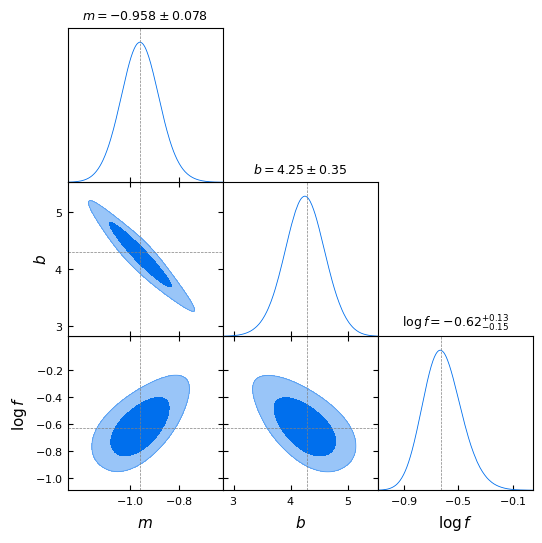

In [303]:
from getdist import MCSamples, plots

outchain = sampler.get_flat_chain(burnin=2000)



samples = MCSamples(
    samples=outchain[::5],
    names=["m","b","logf"],
    labels=["m","b","\\log f"],
    settings={"smooth_scale_2D": 0.8,"smooth_scale_1D": 0.8},
)

g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 2

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4
g.settings.title_limit_fontsize = 12

g.triangle_plot(
    samples, 
    filled=True,     
    markers={
        "m": m_true,
        "b": b_true,
        "logf": numpy.log(f_true)
    },
    title_limit=1)


#g.save